# Setup

**This code was executed using an NVIDIA A100 GPU on Google Colab.**

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json

import tensorflow as tf
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    explained_variance_score,
)

import datetime

plt.rcParams.update(
    {
        "xtick.top": True,
        "ytick.right": True,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "font.size": 14,
        "font.family": "sans-serif",
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        # "axes.spines.top": False,
        # "axes.spines.right": False,
        "legend.frameon": False,
        # "axes.grid" : True,
        # "grid.color": "gray",
        # "grid.linestyle": "--",
        # "grid.linewidth": 0.5,
        # "grid.alpha": 0.3,
    }
)

In [ ]:
def parse_example(
    example_proto,
    input_stats,
    output_stats,
):
    """
    Parse a single tf.train.Example proto using provided normalization statistics.

    Parameters
    ----------
    example_proto : tf.Tensor
        A serialized Example proto containing raw features.
    input_stats : dict
        Normalization statistics for input features. Keys are regions ('UV', 'Vis', 'NIR')
        with corresponding tuples (mean, std).
    output_stats : dict
        Normalization and transformation statistics for output features.

    Returns
    -------
    tuple
        A tuple (normalized_inputs, grouped_outputs) where:
          - normalized_inputs is a dict mapping feature names to normalized tf.Tensor inputs.
          - grouped_outputs is a dict with keys 'physical_output', 'main_chemical_output',
            and 'other_chemical_output', each containing a list of processed output tensors.
    """
    raw_input_features = {
        "NOISY_ALBEDO_SS-NIR": tf.io.VarLenFeature(tf.float32),
        "NOISY_ALBEDO_SS-UV": tf.io.VarLenFeature(tf.float32),
        "NOISY_ALBEDO_SS-Vis": tf.io.VarLenFeature(tf.float32),
    }

    raw_output_features = {
        # Planetary parameters.
        "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
        "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
        "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
        "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
        # Chemical abundances.
        "CH4": tf.io.FixedLenFeature([], tf.float32),
        #'CO':   tf.io.FixedLenFeature([], tf.float32),
        "CO2": tf.io.FixedLenFeature([], tf.float32),
        "H2O": tf.io.FixedLenFeature([], tf.float32),
        "N2": tf.io.FixedLenFeature([], tf.float32),
        #'N2O':  tf.io.FixedLenFeature([], tf.float32),
        "O2": tf.io.FixedLenFeature([], tf.float32),
        "O3": tf.io.FixedLenFeature([], tf.float32),
        # 'Earth_type': tf.io.FixedLenFeature([], tf.string)
    }

    all_features = {**raw_input_features, **raw_output_features}
    parsed = tf.io.parse_single_example(example_proto, all_features)

    # Normalize input spectra.
    normalized_inputs = {}
    for region in ["UV", "Vis", "NIR"]:
        spectrum = parsed[f"NOISY_ALBEDO_SS-{region}"]
        if isinstance(spectrum, tf.SparseTensor):
            spectrum = tf.sparse.to_dense(spectrum, default_value=0.0)

        mean = input_stats[region][0]
        std = input_stats[region][1]
        normalized = (spectrum - mean) / std

        # Reshape for model
        if region == "UV":
            normalized = tf.reshape(normalized, [7, 1])
        elif region == "Vis":
            normalized = tf.reshape(normalized, [109, 1])
        elif region == "NIR":
            normalized = tf.reshape(normalized, [25, 1])

        normalized_inputs[f"NOISY_ALBEDO_SS-{region}"] = normalized

    physical_outputs = []
    main_chemical_outputs = []
    other_chemical_outputs = []

    for param in [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]:
        val = parsed[param]
        # To avoid a very ponctual error we found
        # the floating point precision error generates a single NaN value here :(
        val = tf.where(tf.equal(val, 273.15), val + 2e-5, val)
        min_ = output_stats["physical_output_stats"][param][0]
        max_ = output_stats["physical_output_stats"][param][1]
        processed = (val - min_) / (max_ - min_)
        physical_outputs.append(processed)

    for chem in ["O2", "O3"]:
        val = parsed[chem]
        best_n = output_stats["chemical_output_stats"][chem]["best_n"]
        processed = tf.math.pow(val, 1.0 / best_n)
        main_chemical_outputs.append(processed)

    for chem in ["CH4", "CO2", "H2O", "N2"]:
        val = parsed[chem]
        best_n = output_stats["chemical_output_stats"][chem]["best_n"]
        processed = tf.math.pow(val, 1.0 / best_n)
        other_chemical_outputs.append(processed)

    grouped_outputs = {
        "physical_output": physical_outputs,
        "main_chemical_output": main_chemical_outputs,
        "other_chemical_output": other_chemical_outputs,
        #'earth_type': parsed['Earth_type']
    }

    return normalized_inputs, grouped_outputs


def read_tfrecord(
    file_path, batch_size=1024, shuffle_buffer=None, repeat: bool = False
):
    """
    Read a TFRecord file, parse its examples, and return a batched tf.data.Dataset.

    Parameters
    ----------
    file_path : str
        Path to the TFRecord file.
    batch_size : int, optional
        Number of samples per batch, by default 256.
    shuffle_buffer : int, optional
        Buffer size for shuffling. If None or <= 0, shuffling is not applied.
    repeat : bool, optional
        Whether to repeat the dataset indefinitely, by default False.

    Returns
    -------
    tf.data.Dataset
        A dataset of parsed examples, batched and prefetched.
    """
    with open(
        "/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/DATA/normalization_stats.json"
    ) as f:
        stats = json.load(f)

    input_stats = {
        "UV": (stats["inputs"]["SS-UV"]["mean"], stats["inputs"]["SS-UV"]["std"]),
        "Vis": (stats["inputs"]["SS-Vis"]["mean"], stats["inputs"]["SS-Vis"]["std"]),
        "NIR": (stats["inputs"]["SS-NIR"]["mean"], stats["inputs"]["SS-NIR"]["std"]),
    }

    physical_keys = [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]
    physical_output_stats = {
        key: (
            stats["outputs"][key]["min"],
            stats["outputs"][key]["max"],
        )
        for key in physical_keys
    }

    chemical_keys = ["CH4", "CO2", "H2O", "N2", "O2", "O3"]
    chemical_output_stats = {key: stats["outputs"][key] for key in chemical_keys}

    output_stats = {
        "physical_output_stats": physical_output_stats,
        "chemical_output_stats": chemical_output_stats,
    }

    dataset = tf.data.TFRecordDataset(file_path, num_parallel_reads=tf.data.AUTOTUNE)

    if shuffle_buffer is not None and shuffle_buffer > 0:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    # Parse the dataset using the parse_example function.
    parsed_dataset = dataset.map(
        lambda x: parse_example(x, input_stats, output_stats),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    if repeat:
        parsed_dataset = parsed_dataset.repeat()

    parsed_dataset = parsed_dataset.batch(batch_size, drop_remainder=False)
    parsed_dataset = parsed_dataset.prefetch(tf.data.AUTOTUNE)

    return parsed_dataset

In [3]:
train_ds = read_tfrecord(
    "/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/DATA/train.tfrecord",
    shuffle_buffer=100_000,
    repeat=True,
)
val_ds = read_tfrecord(
    "/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/DATA/val.tfrecord",
    shuffle_buffer=10_000,
    repeat=True,
)
test_ds = read_tfrecord(
    "/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/DATA/test.tfrecord"
)

In [4]:
TRAIN_SAMPLES = 86_596
VAL_SAMPLES = 10_824
BATCH_SIZE = 1024

steps_per_epoch = math.ceil(TRAIN_SAMPLES / BATCH_SIZE)
validation_steps = math.ceil(VAL_SAMPLES / BATCH_SIZE)

# BAYESIAN TUNER

In [5]:
%%capture
!pip install keras-tuner
import kerastuner as kt

In [ ]:
def residual_block_1D(
    x,
    num_filters=32,
    kernel_size=3,
    activation="swish",
    padding="same",
    strides=1,
    dropout_rate=0.25,
):
    shortcut = x
    # First Conv
    y = tf.keras.layers.Conv1D(
        num_filters, kernel_size, padding=padding, activation=None
    )(x)
    y = tf.keras.layers.BatchNormalization()(y)
    y = tf.keras.layers.Activation(activation)(y)
    y = tf.keras.layers.SpatialDropout1D(rate=dropout_rate)(y, training=True)
    # Second Conv
    y = tf.keras.layers.Conv1D(
        num_filters, kernel_size, padding=padding, activation=None
    )(y)
    y = tf.keras.layers.BatchNormalization()(y)
    # Skip connection
    y = tf.keras.layers.Add()([shortcut, y])
    y = tf.keras.layers.Activation(activation)(y)
    # y = tf.keras.layers.MaxPooling1D(pool_size=1)(y)
    y = tf.keras.layers.SpatialDropout1D(rate=dropout_rate)(y, training=True)
    y = tf.keras.layers.Conv1D(
        num_filters, kernel_size, padding=padding, strides=strides, activation=None
    )(y)
    return y


def small_transformer_block(x, num_heads=4, key_dim=32):
    # Self-Attention
    attn_output = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim
    )(x, x)
    x = tf.keras.layers.Add()([x, attn_output])
    x = tf.keras.layers.LayerNormalization()(x)
    # Feed-forward
    ff = tf.keras.layers.Dense(64, activation="swish")(x)
    ff = tf.keras.layers.Dense(x.shape[-1])(ff)  # project back to input feature dim
    x = tf.keras.layers.Add()([x, ff])
    x = tf.keras.layers.LayerNormalization()(x)
    return x


def build_model(hp):
    """
    HyperModel for your CNN with Bayesian optimization. The model:
      - Takes three spectral inputs (UV, VIS, NIR)
      - Merges them and applies two residual blocks with large kernel sizes for near-global coverage
      - Applies a small transformer block
      - Uses dense layers with dropout, and two sub-heads for physical and chemical outputs.
    """
    physical_targets = [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]
    main_chemical_targets = ["O2", "O3"]
    other_chemical_targets = ["CH4", "CO2", "H2O", "N2"]

    input_uv = tf.keras.layers.Input(shape=(7, 1), name="NOISY_ALBEDO_SS-UV")
    input_vis = tf.keras.layers.Input(shape=(109, 1), name="NOISY_ALBEDO_SS-Vis")
    input_nir = tf.keras.layers.Input(shape=(25, 1), name="NOISY_ALBEDO_SS-NIR")
    # Concatenate along the spectral dimension.
    spectrum = tf.keras.layers.Concatenate(axis=1)([input_uv, input_vis, input_nir])
    spectrum_length = 141  # Total length

    # Convolutional block hyperparameters
    num_filters = hp.Int("num_filters", min_value=16, max_value=64, step=8, default=20)
    kernel_size_1 = hp.Choice(
        "kernel_size_1",
        values=[
            max(3, int(spectrum_length / 4)),
            int(spectrum_length / 3),
            int(spectrum_length / 2),
        ],
        default=int(spectrum_length / 4),
    )
    kernel_size_2 = hp.Choice(
        "kernel_size_2",
        values=[int(spectrum_length / 2), int(spectrum_length * 0.75), spectrum_length],
        default=int(spectrum_length / 2),
    )
    # Transformer block hyperparameters
    num_heads = hp.Int("num_heads", min_value=2, max_value=4, step=1, default=2)
    key_dim = hp.Int("key_dim", min_value=8, max_value=16, step=4, default=8)
    # Dense block and dropout hyperparameters
    dense_units = hp.Int("dense_units", min_value=16, max_value=64, step=16, default=32)
    dropout_rate = hp.Float(
        "dropout_rate", min_value=0.25, max_value=0.5, step=0.05, default=0.25
    )
    # Optimizer learning rate
    learning_rate = hp.Float(
        "learning_rate", min_value=1e-5, max_value=1e-3, sampling="LOG", default=1e-4
    )

    # Residual blocks with large kernels for near-global coverage.
    spectrum = residual_block_1D(
        spectrum,
        num_filters=num_filters,
        kernel_size=kernel_size_1,
        strides=2,
        dropout_rate=dropout_rate,
    )
    spectrum = residual_block_1D(
        spectrum,
        num_filters=num_filters,
        kernel_size=kernel_size_2,
        strides=2,
        dropout_rate=dropout_rate,
    )
    # Transformer block
    spectrum = small_transformer_block(spectrum, num_heads=num_heads, key_dim=key_dim)
    # Global pooling to reduce dimensionality.
    spectrum = tf.keras.layers.GlobalAveragePooling1D()(spectrum)

    # Dense layers with skip connection.
    shortcut = tf.keras.layers.Dense(dense_units, kernel_initializer="he_normal")(
        spectrum
    )
    x = tf.keras.layers.Dropout(dropout_rate)(shortcut, training=True)
    x = tf.keras.layers.Dense(
        dense_units, kernel_initializer="he_normal", activation="swish"
    )(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x, training=True)
    x = tf.keras.layers.Dense(
        dense_units, kernel_initializer="he_normal", activation="swish"
    )(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x, training=True)
    x = tf.keras.layers.Add()([shortcut, x])

    # Physical parameters head
    phys = tf.keras.layers.Dense(dense_units // 2, kernel_initializer="glorot_uniform")(
        x
    )
    phys_out = tf.keras.layers.Dense(
        len(physical_targets), activation="sigmoid", name="physical_output"
    )(phys)

    # Main chemical abundances head
    main_chem = tf.keras.layers.Dense(dense_units // 2, kernel_initializer="he_normal")(
        x
    )
    main_chem_out_dense = tf.keras.layers.Dense(
        len(main_chemical_targets), activation=None, name="main_chem_dense"
    )(main_chem)
    main_chem_out = tf.keras.layers.ReLU(max_value=1.0, name="main_chemical_output")(
        main_chem_out_dense
    )

    # Other chemical abundances head
    other_chem = tf.keras.layers.Dense(
        dense_units // 2, kernel_initializer="he_normal"
    )(x)
    other_chem_out_dense = tf.keras.layers.Dense(
        len(other_chemical_targets), activation=None, name="other_chem_dense"
    )(other_chem)
    other_chem_out = tf.keras.layers.ReLU(max_value=1.0, name="other_chemical_output")(
        other_chem_out_dense
    )

    outputs = {
        "physical_output": phys_out,
        "main_chemical_output": main_chem_out,
        "other_chemical_output": other_chem_out,
    }

    model = tf.keras.Model(
        inputs=[input_uv, input_vis, input_nir], outputs=outputs, name="cnn_hyper"
    )

    losses = {
        "physical_output": "mae",
        "main_chemical_output": "mae",
        "other_chemical_output": "mae",
    }
    loss_weights = {
        "physical_output": 1.0,
        "main_chemical_output": 2.0,
        "other_chemical_output": 1.5,
    }
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss=losses, loss_weights=loss_weights)

    return model

In [13]:
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_loss",
    max_trials=35,
    directory="/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/hypertuning_HabEx",
    project_name="cnn_bayesian_optimization",
)

In [14]:
# Total elapsed time: 28m 16s
tuner.search(
    train_ds,
    epochs=3,
    validation_data=val_ds,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
)

Trial 35 Complete [00h 00m 41s]
val_loss: 0.7179507613182068

Best val_loss So Far: 0.37849709391593933
Total elapsed time: 00h 28m 16s


In [15]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
display("Best hyperparameters:", best_hp.values)

'Best hyperparameters:'

{'num_filters': 16,
 'kernel_size_1': 70,
 'kernel_size_2': 141,
 'num_heads': 3,
 'key_dim': 16,
 'dense_units': 16,
 'dropout_rate': 0.25,
 'learning_rate': 0.00026206728321924964}

In [16]:
best_model = tuner.hypermodel.build(best_hp)

In [24]:
EPOCHS = 100

log_dir = (
    "/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/logs_habex/fit/"
    + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor="val_loss",
#     factor=0.6,  # How much to reduce LR by
#     patience=5,  # Wait 3 epochs with no improvement before reducing LR
#     min_lr=1e-7,  # Lower bound on LR
#     cooldown=0,
#     verbose=1,
# )

early_stop_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,  # Number of epochs with no improvement after which training stops
    restore_best_weights=True,  # Revert to the best weights found during training
    verbose=1,
)

history = best_model.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=[tensorboard_callback, early_stop_callback],
)

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.1900 - main_chemical_output_loss: 0.0177 - other_chemical_output_loss: 0.0348 - physical_output_loss: 0.1025 - val_loss: 0.1815 - val_main_chemical_output_loss: 0.0144 - val_other_chemical_output_loss: 0.0308 - val_physical_output_loss: 0.1064
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.1879 - main_chemical_output_loss: 0.0175 - other_chemical_output_loss: 0.0339 - physical_output_loss: 0.1020 - val_loss: 0.1721 - val_main_chemical_output_loss: 0.0142 - val_other_chemical_output_loss: 0.0318 - val_physical_output_loss: 0.0960
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.1873 - main_chemical_output_loss: 0.0173 - other_chemical_output_loss: 0.0338 - physical_output_loss: 0.1019 - val_loss: 0.1660 - val_main_chemical_output_loss: 0.0142 - val_other_chemical_output_loss: 0.0286 - val_physical_output_loss: 0.0948
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.1867 - main_chemical

50 + 55 = 105 epochs

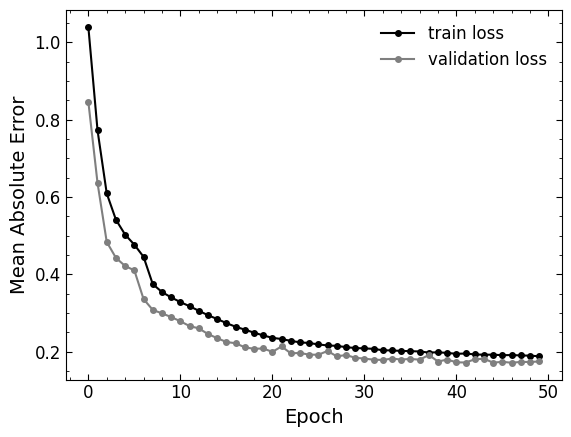

In [19]:
plt.plot(
    range(EPOCHS),
    history.history["loss"],
    marker="o",
    label="train loss",
    color="k",
    markersize=4,
)
plt.plot(
    range(EPOCHS),
    history.history["val_loss"],
    marker="o",
    label="validation loss",
    color="tab:gray",
    markersize=4,
)
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.savefig("/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/IMAGES/loss_habex.png")
plt.show()

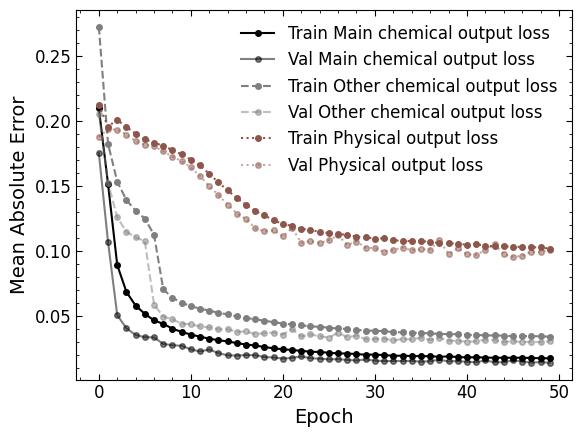

In [ ]:
plt.plot(
    range(EPOCHS),
    history.history["main_chemical_output_loss"],
    marker="o",
    label="Train Main chemical output loss",
    color="k",
    markersize=4,
)
plt.plot(
    range(EPOCHS),
    history.history["val_main_chemical_output_loss"],
    marker="o",
    label="Val Main chemical output loss",
    color="k",
    alpha=0.5,
    markersize=4,
)

plt.plot(
    range(EPOCHS),
    history.history["other_chemical_output_loss"],
    marker="o",
    ls="dashed",
    label="Train Other chemical output loss",
    color="tab:gray",
    markersize=4,
)
plt.plot(
    range(EPOCHS),
    history.history["val_other_chemical_output_loss"],
    marker="o",
    ls="dashed",
    label="Val Other chemical output loss",
    color="tab:gray",
    alpha=0.5,
    markersize=4,
)

plt.plot(
    range(EPOCHS),
    history.history["physical_output_loss"],
    marker="o",
    ls="dotted",
    label="Train Physical output loss",
    color="tab:brown",
    markersize=4,
)
plt.plot(
    range(EPOCHS),
    history.history["val_physical_output_loss"],
    marker="o",
    ls="dotted",
    label="Val Physical output loss",
    color="tab:brown",
    alpha=0.5,
    markersize=4,
)

plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.savefig(
    "/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/IMAGES/complete_loss_habex.png"
)
plt.show()

In [25]:
best_model.save("/content/drive/MyDrive/CNN-MODELS-DEZ-VERSION/habex_model.keras")

# TESTING

In [27]:
y_true_phys_all = []
y_true_main_chem_all = []
y_true_other_chem_all = []

y_pred_phys_all = []
y_pred_main_chem_all = []
y_pred_other_chem_all = []

for x_batch, y_batch in test_ds:
    # 1) Get model predictions for this batch
    predictions = best_model(x_batch, training=False)
    pred_phys_batch = predictions["physical_output"]
    pred_main_chem_batch = predictions["main_chemical_output"]
    pred_other_chem_batch = predictions["other_chemical_output"]

    # 2) Collect ground-truth values
    true_phys_batch = y_batch["physical_output"]
    true_main_chem_batch = y_batch["main_chemical_output"]
    true_other_chem_batch = y_batch["other_chemical_output"]

    # 3) Append to our running lists
    y_true_phys_all.append(true_phys_batch.numpy())
    y_true_main_chem_all.append(true_main_chem_batch.numpy())
    y_true_other_chem_all.append(true_other_chem_batch.numpy())

    y_pred_phys_all.append(pred_phys_batch.numpy())
    y_pred_main_chem_all.append(pred_main_chem_batch.numpy())
    y_pred_other_chem_all.append(pred_other_chem_batch.numpy())

# 4) Concatenate the list of batches into a single array for each head
y_true_phys_all = np.concatenate(y_true_phys_all, axis=0)
y_true_main_chem_all = np.concatenate(y_true_main_chem_all, axis=0)
y_true_other_chem_all = np.concatenate(y_true_other_chem_all, axis=0)

y_pred_phys_all = np.concatenate(y_pred_phys_all, axis=0)
y_pred_main_chem_all = np.concatenate(y_pred_main_chem_all, axis=0)
y_pred_other_chem_all = np.concatenate(y_pred_other_chem_all, axis=0)

,Output,R²,Explained Variance,MSE,RMSE,MAE,Median AE,RMedSE,MAPE (%),MedAPE (%),sMAPE (%),WAPE (%),NMAE (range-normalized)
0,Radius,0.837305,0.838453,0.007637,0.087392,0.065364,0.049673,0.049673,12.462135,7.110800,11.202715,9.339529,0.066025
1,Gravity,0.833428,0.834742,0.007801,0.088323,0.066454,0.051267,0.051267,14.727662,7.942981,12.075078,10.206296,0.066507
2,Temperature,0.376994,0.377003,0.024461,0.156401,0.123652,0.102241,0.102241,532.024353,44.572975,62.813843,51.234329,0.129055
3,Pressure,0.826379,0.827832,0.009941,0.099707,0.075018,0.058015,0.058015,17.929428,10.961355,15.925312,13.311638,0.075828


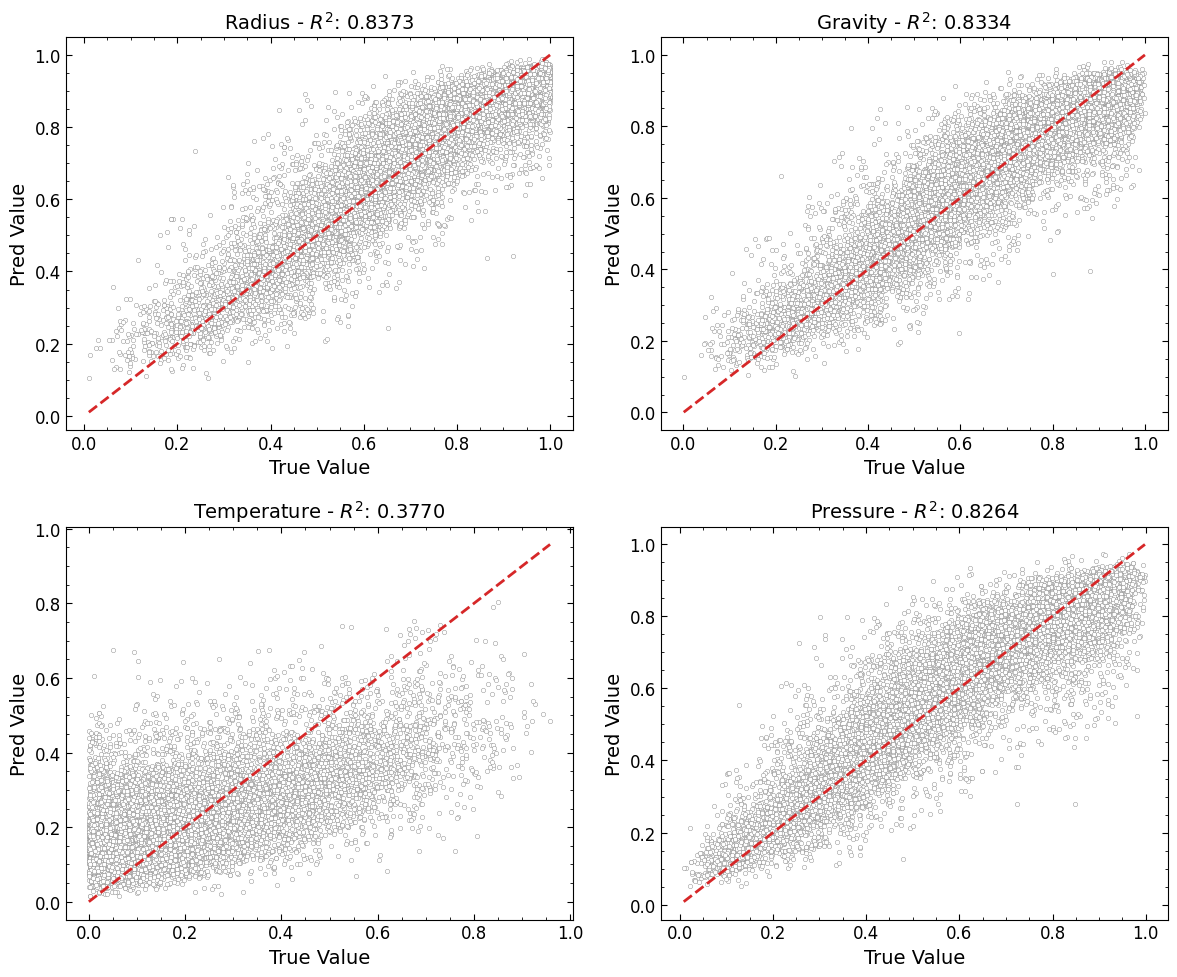

In [ ]:
physical_parameters = ["Radius", "Gravity", "Temperature", "Pressure"]
n_keys = len(physical_parameters)
n_cols = 2
n_rows = int(np.ceil(n_keys / n_cols))

plt.figure(figsize=(12, 10))

metrics_list = []

for i, phys_param in enumerate(physical_parameters):
    phys_true = np.array(
        [y_true_phys_all[row][i] for row in range(len(y_true_phys_all))]
    )
    phys_pred = np.array(
        [y_pred_phys_all[row][i] for row in range(len(y_pred_phys_all))]
    )

    min_val = min(phys_true.min(), phys_pred.min())
    max_val = max(phys_true.max(), phys_pred.max())

    r2 = r2_score(phys_true, phys_pred)
    mse = mean_squared_error(phys_true, phys_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(phys_true, phys_pred)
    med_ae = median_absolute_error(phys_true, phys_pred)
    exp_var = explained_variance_score(phys_true, phys_pred)

    err = phys_pred - phys_true
    ae = np.abs(err)
    se = err**2

    # MAPE / MedAPE
    mask_true_nz = np.abs(phys_true) > 0
    if np.any(mask_true_nz):
        ape = ae[mask_true_nz] / np.abs(phys_true[mask_true_nz])
        mape = np.mean(ape) * 100.0
        medape = np.median(ape) * 100.0
    else:
        mape = np.nan
        medape = np.nan

    # RMedSE (root median squared error)
    rmedse = np.sqrt(np.median(se))

    # sMAPE
    denom = np.abs(phys_true) + np.abs(phys_pred)
    mask_denom_nz = denom > 0
    if np.any(mask_denom_nz):
        smape = np.mean(2.0 * ae[mask_denom_nz] / denom[mask_denom_nz]) * 100.0
    else:
        smape = np.nan

    # WAP
    denom_wape = np.sum(np.abs(phys_true))
    if denom_wape > 0:
        wape = np.sum(ae) / denom_wape * 100.0
    else:
        wape = np.nan

    # NMAE
    range_true = phys_true.max() - phys_true.min()
    if range_true > 0:
        nmae = mae / range_true
    else:
        nmae = np.nan

    ax = plt.subplot(n_rows, n_cols, i + 1)
    ax.plot([min_val, max_val], [min_val, max_val], ls="--", color="tab:red", lw=2)

    ax.scatter(
        phys_true, phys_pred, s=10, edgecolor="tab:gray", linewidth=0.3, color="w"
    )

    ax.set_title(rf"{physical_parameters[i]} - $R^2$: {r2:.4f}")
    ax.set_xlabel("True Value")
    ax.set_ylabel("Pred Value")

    metrics_list.append(
        {
            "Output": phys_param,
            "R²": r2,
            "Explained Variance": exp_var,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "Median AE": med_ae,
            "RMedSE": rmedse,
            "MAPE (%)": mape,
            "MedAPE (%)": medape,
            "sMAPE (%)": smape,
            "WAPE (%)": wape,
            "NMAE (range-normalized)": nmae,
        }
    )

plt.tight_layout()

df_metrics = pd.DataFrame(metrics_list)
df_metrics

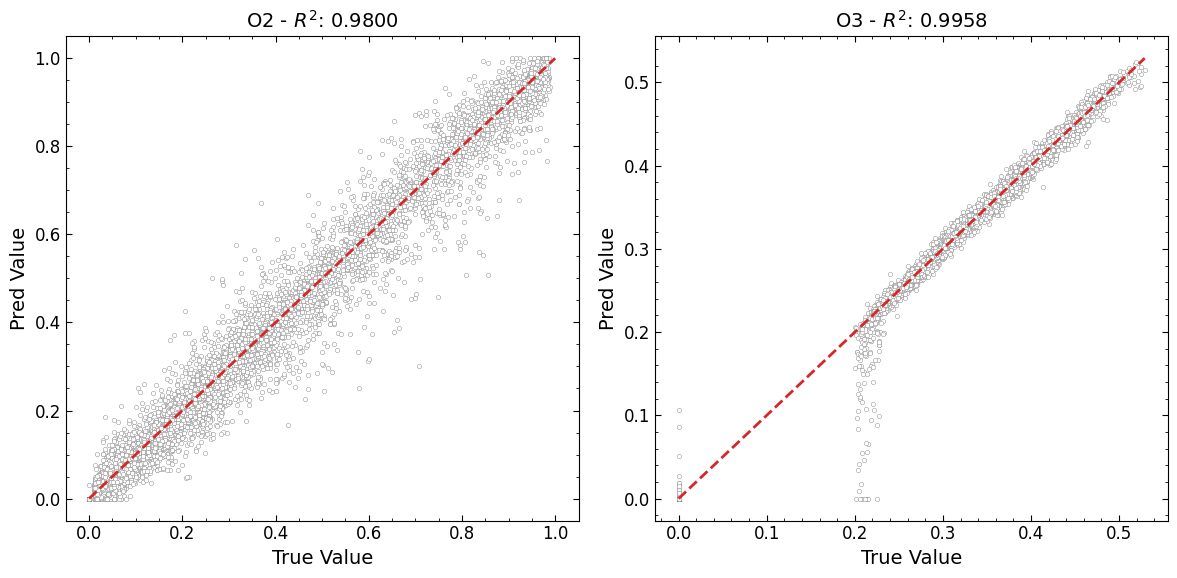

,Output,R²,Explained Variance,MSE,RMSE,MAE,Median AE,RMedSE,MAPE (%),MedAPE (%),sMAPE (%),WAPE (%),NMAE (range-normalized)
0,O2,0.979991,0.980094,0.001670,0.040871,0.022667,0.010180,0.010180,19.906292,11.160260,20.122334,10.095036,0.022941
1,O3,0.995758,0.995758,0.000115,0.010724,0.004079,0.002063,0.002063,1.947308,1.238198,2.657790,1.783818,0.007710


In [ ]:
main_chemical_parameters = ["O2", "O3"]

n_keys = len(main_chemical_parameters)
n_cols = 2
n_rows = int(np.ceil(n_keys / n_cols))

plt.figure(figsize=(12, 6))

metrics_list = []

for i, chem_param in enumerate(main_chemical_parameters):
    chem_true = np.array(
        [y_true_main_chem_all[row][i] for row in range(len(y_true_main_chem_all))]
    )
    chem_pred = np.array(
        [y_pred_main_chem_all[row][i] for row in range(len(y_pred_main_chem_all))]
    )

    min_val = min(chem_true.min(), chem_pred.min())
    max_val = max(chem_true.max(), chem_pred.max())

    r2 = r2_score(chem_true, chem_pred)
    mse = mean_squared_error(chem_true, chem_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(chem_true, chem_pred)
    med_ae = median_absolute_error(chem_true, chem_pred)
    exp_var = explained_variance_score(chem_true, chem_pred)

    err = chem_pred - chem_true
    ae = np.abs(err)
    se = err**2

    mask_true_nz = np.abs(chem_true) > 0
    if np.any(mask_true_nz):
        ape = ae[mask_true_nz] / np.abs(chem_true[mask_true_nz])
        mape = np.mean(ape) * 100.0
        medape = np.median(ape) * 100.0
    else:
        mape = np.nan
        medape = np.nan

    rmedse = np.sqrt(np.median(se))

    denom = np.abs(chem_true) + np.abs(chem_pred)
    mask_denom_nz = denom > 0
    if np.any(mask_denom_nz):
        smape = np.mean(2.0 * ae[mask_denom_nz] / denom[mask_denom_nz]) * 100.0
    else:
        smape = np.nan

    denom_wape = np.sum(np.abs(chem_true))
    if denom_wape > 0:
        wape = np.sum(ae) / denom_wape * 100.0
    else:
        wape = np.nan

    range_true = chem_true.max() - chem_true.min()
    if range_true > 0:
        nmae = mae / range_true
    else:
        nmae = np.nan

    ax = plt.subplot(n_rows, n_cols, i + 1)
    ax.plot([min_val, max_val], [min_val, max_val], ls="--", color="tab:red", lw=2)

    ax.scatter(
        chem_true, chem_pred, s=10, edgecolor="tab:gray", linewidth=0.3, color="w"
    )

    ax.set_title(rf"{chem_param} - $R^2$: {r2:.4f}")
    ax.set_xlabel("True Value")
    ax.set_ylabel("Pred Value")

    metrics_list.append(
        {
            "Output": chem_param,
            "R²": r2,
            "Explained Variance": exp_var,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "Median AE": med_ae,
            "RMedSE": rmedse,
            "MAPE (%)": mape,
            "MedAPE (%)": medape,
            "sMAPE (%)": smape,
            "WAPE (%)": wape,
            "NMAE (range-normalized)": nmae,
        }
    )

plt.tight_layout()
plt.show()

df_metrics_chem = pd.DataFrame(metrics_list)
df_metrics_chem

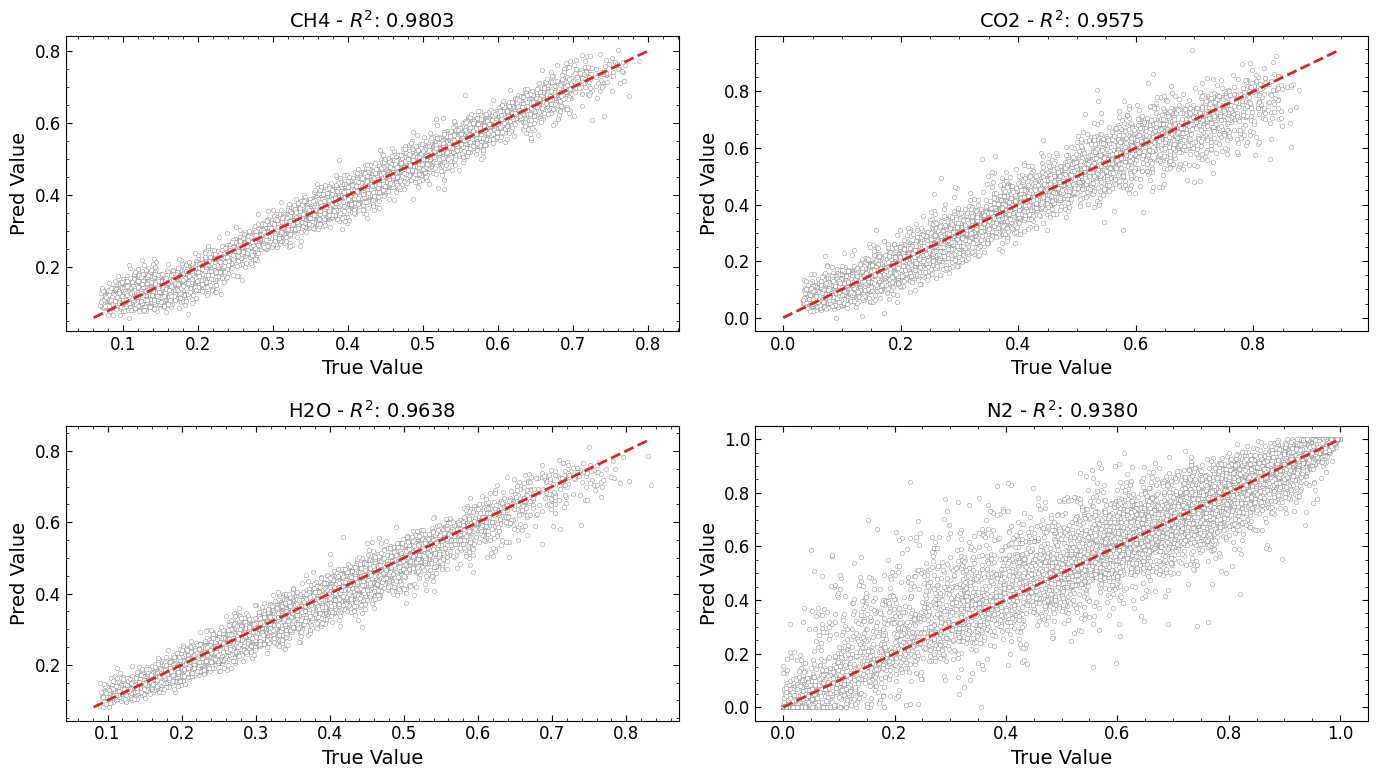

,Output,R²,Explained Variance,MSE,RMSE,MAE,Median AE,RMedSE,MAPE (%),MedAPE (%),sMAPE (%),WAPE (%),NMAE (range-normalized)
0,CH4,0.980292,0.980366,0.000533,0.023080,0.017431,0.013335,0.013335,7.841305,4.128381,7.725986,5.212508,0.024246
1,CO2,0.957456,0.957750,0.001435,0.037881,0.025891,0.017687,0.017687,12.285997,7.452387,11.933597,9.079523,0.030647
2,H2O,0.963787,0.967402,0.000565,0.023773,0.017540,0.013233,0.013233,5.962112,4.687317,6.091098,5.640542,0.023567
3,N2,0.937997,0.939474,0.005904,0.076840,0.045566,0.020842,0.020842,29.502878,3.352742,20.584103,6.509509,0.045597


In [ ]:
other_chemical_parameters = ["CH4", "CO2", "H2O", "N2"]

n_keys = len(other_chemical_parameters)
n_cols = 2
n_rows = 2
plt.figure(figsize=(14, 8))

metrics_list = []

for i, chem_param in enumerate(other_chemical_parameters):
    chem_true = np.array(
        [y_true_other_chem_all[row][i] for row in range(len(y_true_other_chem_all))]
    )
    chem_pred = np.array(
        [y_pred_other_chem_all[row][i] for row in range(len(y_pred_other_chem_all))]
    )

    min_val = min(chem_true.min(), chem_pred.min())
    max_val = max(chem_true.max(), chem_pred.max())

    r2 = r2_score(chem_true, chem_pred)
    mse = mean_squared_error(chem_true, chem_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(chem_true, chem_pred)
    med_ae = median_absolute_error(chem_true, chem_pred)
    exp_var = explained_variance_score(chem_true, chem_pred)

    err = chem_pred - chem_true
    ae = np.abs(err)
    se = err**2

    mask_true_nz = np.abs(chem_true) > 0
    if np.any(mask_true_nz):
        ape = ae[mask_true_nz] / np.abs(chem_true[mask_true_nz])
        mape = np.mean(ape) * 100.0
        medape = np.median(ape) * 100.0
    else:
        mape = np.nan
        medape = np.nan

    rmedse = np.sqrt(np.median(se))

    denom = np.abs(chem_true) + np.abs(chem_pred)
    mask_denom_nz = denom > 0
    if np.any(mask_denom_nz):
        smape = np.mean(2.0 * ae[mask_denom_nz] / denom[mask_denom_nz]) * 100.0
    else:
        smape = np.nan

    denom_wape = np.sum(np.abs(chem_true))
    if denom_wape > 0:
        wape = np.sum(ae) / denom_wape * 100.0
    else:
        wape = np.nan

    range_true = chem_true.max() - chem_true.min()
    if range_true > 0:
        nmae = mae / range_true
    else:
        nmae = np.nan

    ax = plt.subplot(n_rows, n_cols, i + 1)
    ax.plot([min_val, max_val], [min_val, max_val], ls="--", color="tab:red", lw=2)

    ax.scatter(
        chem_true, chem_pred, s=10, edgecolor="tab:gray", linewidth=0.3, color="w"
    )

    ax.set_title(rf"{chem_param} - $R^2$: {r2:.4f}")
    ax.set_xlabel("True Value")
    ax.set_ylabel("Pred Value")

    metrics_list.append(
        {
            "Output": chem_param,
            "R²": r2,
            "Explained Variance": exp_var,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "Median AE": med_ae,
            "RMedSE": rmedse,
            "MAPE (%)": mape,
            "MedAPE (%)": medape,
            "sMAPE (%)": smape,
            "WAPE (%)": wape,
            "NMAE (range-normalized)": nmae,
        }
    )

plt.tight_layout()
plt.show()

df_metrics_other_chem = pd.DataFrame(metrics_list)
df_metrics_other_chem